In [2]:
import pandas as pd
import numpy as np

sales = pd.read_csv("../data/raw/sales_train_evaluation.csv")
calendar = pd.read_csv("../data/raw/calendar.csv")
prices = pd.read_csv("../data/raw/sell_prices.csv")

print("Calendar date range:", calendar['date'].min(), "to", calendar['date'].max())
print("Sales shape:", sales.shape)
print("States:", sales['state_id'].unique())
print("Categories:", sales['cat_id'].unique())

Calendar date range: 2011-01-29 to 2016-06-19
Sales shape: (30490, 1947)
States: <ArrowStringArray>
['CA', 'TX', 'WI']
Length: 3, dtype: str
Categories: <ArrowStringArray>
['HOBBIES', 'HOUSEHOLD', 'FOODS']
Length: 3, dtype: str


In [3]:
scoped = sales[(sales['state_id'] == 'CA') & (sales['cat_id'] == 'FOODS')].copy()
print("SKU-store rows in scope:", scoped.shape[0])
print("Unique items:", scoped['item_id'].nunique())

# day columns are d_1, d_2, ... d_1941
day_cols = [c for c in scoped.columns if c.startswith('d_')]

# aggregate across CA's stores -> one row per item_id
item_level = scoped.groupby('item_id')[day_cols].sum().reset_index()
print("Aggregated item-level series:", item_level.shape)

SKU-store rows in scope: 5748
Unique items: 1437
Aggregated item-level series: (1437, 1942)


In [4]:
long_df = item_level.melt(id_vars='item_id', var_name='d', value_name='sales')
long_df = long_df.merge(calendar[['d', 'date']], on='d', how='left')
long_df['date'] = pd.to_datetime(long_df['date'])
long_df = long_df.sort_values(['item_id', 'date']).reset_index(drop=True)
long_df.head()

,item_id,d,sales,date
0,FOODS_1_001,d_1,6,2011-01-29
1,FOODS_1_001,d_2,3,2011-01-30
2,FOODS_1_001,d_3,2,2011-01-31
3,FOODS_1_001,d_4,3,2011-02-01
4,FOODS_1_001,d_5,7,2011-02-02


In [5]:
item_stats = long_df.groupby('item_id')['sales'].agg(
    total_sales='sum',
    mean_sales='mean',
    std_sales='std'
).reset_index()
item_stats['cv'] = item_stats['std_sales'] / item_stats['mean_sales']  # coefficient of variation

# ABC: by revenue/volume contribution (using total_sales as proxy; swap in $ if you bring in prices)
item_stats = item_stats.sort_values('total_sales', ascending=False).reset_index(drop=True)
item_stats['cum_pct'] = item_stats['total_sales'].cumsum() / item_stats['total_sales'].sum()
item_stats['abc_class'] = pd.cut(item_stats['cum_pct'], bins=[0, 0.7, 0.9, 1.0], labels=['A', 'B', 'C'])

# XYZ: by variability (coefficient of variation)
item_stats['xyz_class'] = pd.cut(item_stats['cv'], bins=[0, 0.5, 1.0, np.inf], labels=['X', 'Y', 'Z'])

item_stats['segment'] = item_stats['abc_class'].astype(str) + item_stats['xyz_class'].astype(str)
print(item_stats['segment'].value_counts())

segment
CZ    566
BY    283
AY    257
BZ    149
CY     79
AZ     60
AX     43
Name: count, dtype: int64


In [7]:
import os

for folder in ["../data/raw", "../data/interim", "../data/processed",
               "../outputs/figures", "../outputs/tables", "../src"]:
    os.makedirs(folder, exist_ok=True)

In [8]:
# A/X and A/Y items: high-volume, low-to-moderate variability -> best candidates for structural break detection
candidates = item_stats[item_stats['segment'].isin(['AX', 'AY'])]['item_id'].tolist()
print(f"{len(candidates)} items selected for structural break analysis")

long_df[long_df['item_id'].isin(candidates)].to_csv("../data/interim/scoped_sales_candidates.csv", index=False)
item_stats.to_csv("../data/interim/item_segmentation.csv", index=False)

300 items selected for structural break analysis


C:\Users\Anushka\AppData\Local\Temp\ipykernel_3324\1928566610.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)


ADF Statistic: -4.2792, p-value: 0.0005


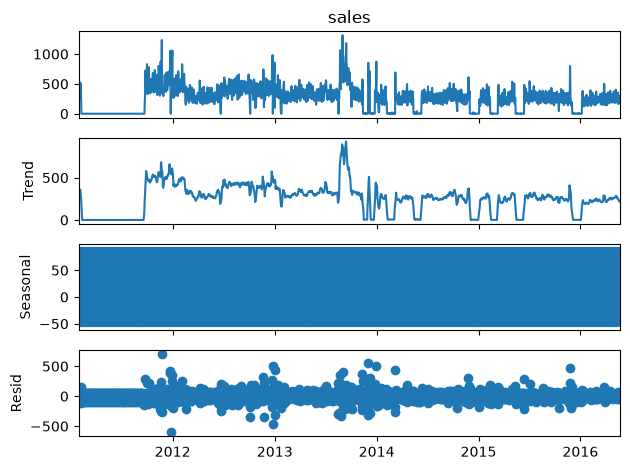

In [9]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

sample_item = candidates[0]
series = long_df[long_df['item_id'] == sample_item].set_index('date')['sales']

result = adfuller(series)
print(f"ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")
# p < 0.05 -> stationary; p >= 0.05 -> non-stationary, needs differencing or is trend/seasonal-driven

decomposition = seasonal_decompose(series, model='additive', period=7)  # weekly seasonality
decomposition.plot()
plt.savefig("../outputs/figures/sample_decomposition.png")
plt.show()

In [10]:
def trim_leading_zeros(df):
    """Keep only rows from an item's first non-zero sale date onward."""
    trimmed = []
    for item_id, grp in df.groupby('item_id'):
        grp = grp.sort_values('date')
        first_sale_idx = grp['sales'].to_numpy().nonzero()[0]
        if len(first_sale_idx) == 0:
            continue  # item never sold in this scope — drop it
        start_pos = first_sale_idx[0]
        trimmed.append(grp.iloc[start_pos:])
    return pd.concat(trimmed, ignore_index=True)

long_df = trim_leading_zeros(long_df)

In [11]:
# sanity check: does the flat zero-stretch still exist?
sample = long_df[long_df['item_id'] == 'FOODS_1_001']
print(sample['date'].min(), "to", sample['date'].max())  # should start later than 2011-01-29 now
print(sample['sales'].head(10))

2011-01-29 00:00:00 to 2016-05-22 00:00:00
0    6
1    3
2    2
3    3
4    7
5    5
6    8
7    3
8    5
9    2
Name: sales, dtype: int64


In [12]:
item_stats = long_df.groupby('item_id')['sales'].agg(
    total_sales='sum',
    mean_sales='mean',
    std_sales='std'
).reset_index()
item_stats['cv'] = item_stats['std_sales'] / item_stats['mean_sales']  # coefficient of variation

# ABC: by revenue/volume contribution (using total_sales as proxy; swap in $ if you bring in prices)
item_stats = item_stats.sort_values('total_sales', ascending=False).reset_index(drop=True)
item_stats['cum_pct'] = item_stats['total_sales'].cumsum() / item_stats['total_sales'].sum()
item_stats['abc_class'] = pd.cut(item_stats['cum_pct'], bins=[0, 0.7, 0.9, 1.0], labels=['A', 'B', 'C'])

# XYZ: by variability (coefficient of variation)
item_stats['xyz_class'] = pd.cut(item_stats['cv'], bins=[0, 0.5, 1.0, np.inf], labels=['X', 'Y', 'Z'])

item_stats['segment'] = item_stats['abc_class'].astype(str) + item_stats['xyz_class'].astype(str)
print(item_stats['segment'].value_counts())

segment
CZ    364
BY    363
CY    281
AY    280
BZ     66
AX     57
AZ     23
BX      3
Name: count, dtype: int64


In [13]:
# find items that actually had leading zeros in the ORIGINAL long_df (before trim)
# if you still have the pre-trim dataframe saved, use it; otherwise reload sales and rebuild long_df fresh to compare

raw_check = sales[(sales['state_id']=='CA') & (sales['cat_id']=='FOODS')]
day_cols = [c for c in raw_check.columns if c.startswith('d_')]
item_level_raw = raw_check.groupby('item_id')[day_cols].sum()

items_with_leading_zeros = []
for item_id, row in item_level_raw.iterrows():
    vals = row.to_numpy()
    if vals[0] == 0:  # first day was zero -> candidate for leading zero stretch
        first_nonzero = vals.nonzero()[0]
        if len(first_nonzero) > 0 and first_nonzero[0] > 30:  # at least a month of leading zeros
            items_with_leading_zeros.append(item_id)

print(f"{len(items_with_leading_zeros)} items had a real leading-zero stretch")
test_item = items_with_leading_zeros[0]
print("Testing:", test_item)

before = item_level_raw.loc[test_item]
print("First 10 raw values:", before.values[:10])

after = long_df[long_df['item_id'] == test_item].sort_values('date')
print("Trimmed start date:", after['date'].min())
print("First 10 trimmed sales:", after['sales'].head(10).tolist())

714 items had a real leading-zero stretch
Testing: FOODS_1_004
First 10 raw values: [0 0 0 0 0 0 0 0 0 0]
Trimmed start date: 2012-03-07 00:00:00
First 10 trimmed sales: [1, 48, 50, 53, 56, 36, 49, 81, 54, 74]


In [14]:
# spot-check a few more, including one from the "already fine" list and one with a very short life
print("Items with real leading-zero stretch:", len(items_with_leading_zeros))
print("Sample check on 3 more:")
for iid in items_with_leading_zeros[1:4]:
    trimmed = long_df[long_df['item_id'] == iid].sort_values('date')
    print(iid, "-> start:", trimmed['date'].min(), "first sales:", trimmed['sales'].head(5).tolist())

# also confirm total row count dropped sensibly
print("Total rows after trim:", len(long_df))

Items with real leading-zero stretch: 714
Sample check on 3 more:
FOODS_1_008 -> start: 2011-10-19 00:00:00 first sales: [2, 2, 1, 1, 0]
FOODS_1_009 -> start: 2012-03-04 00:00:00 first sales: [5, 0, 1, 0, 2]
FOODS_1_010 -> start: 2011-07-31 00:00:00 first sales: [5, 0, 4, 0, 0]
Total rows after trim: 2279871


<Axes: >

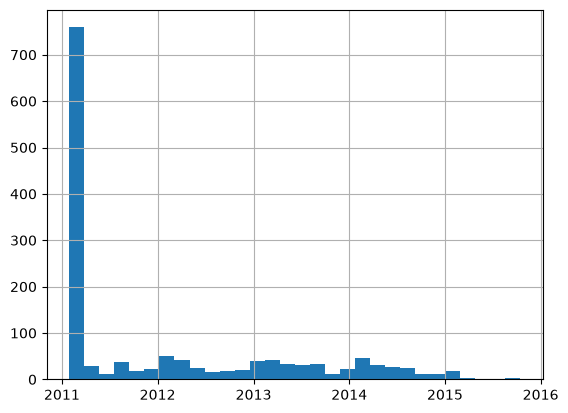

In [15]:
launch_dates = long_df.groupby('item_id')['date'].min()
launch_dates.hist(bins=30)

C:\Users\Anushka\AppData\Local\Temp\ipykernel_3324\4201343586.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)


ADF Statistic: -4.4880, p-value: 0.0002


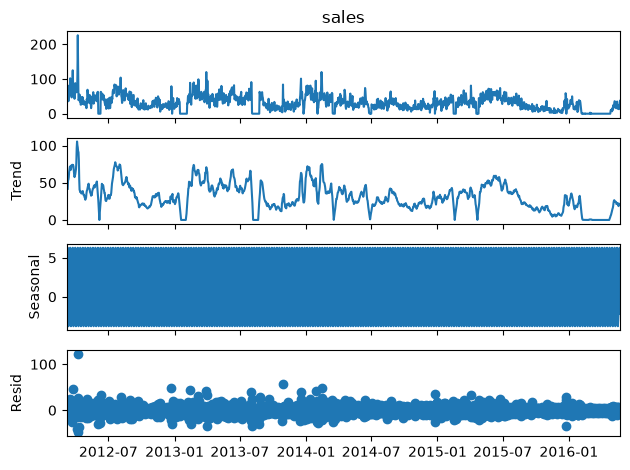

In [16]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

test_item = 'FOODS_1_004'
series = long_df[long_df['item_id'] == test_item].set_index('date')['sales']

result = adfuller(series)
print(f"ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")

decomposition = seasonal_decompose(series, model='additive', period=7)
decomposition.plot()
plt.savefig("../outputs/figures/foods_1_004_decomposition.png")
plt.show()

In [17]:
adf_results = []

for item_id in candidates:
    series = long_df[long_df['item_id'] == item_id].set_index('date')['sales']
    if len(series) < 30:  # skip items with too little history to test meaningfully
        continue
    try:
        result = adfuller(series)
        adf_results.append({'item_id': item_id, 'adf_stat': result[0], 'p_value': result[1]})
    except Exception as e:
        print(f"Failed on {item_id}: {e}")

adf_df = pd.DataFrame(adf_results)
adf_df['is_stationary'] = adf_df['p_value'] < 0.05
print(adf_df['is_stationary'].value_counts())
print(f"{adf_df['is_stationary'].mean()*100:.1f}% of items are stationary at 5% significance")

C:\Users\Anushka\AppData\Local\Temp\ipykernel_3324\2594972538.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)
C:\Users\Anushka\AppData\Local\Temp\ipykernel_3324\2594972538.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)
C:\Users\Anushka\AppData\Local\Temp\ipykernel_3324\2594972538.py:8: FutureWarning: adfuller cu

is_stationary
True     255
False     45
Name: count, dtype: int64
85.0% of items are stationary at 5% significance


C:\Users\Anushka\AppData\Local\Temp\ipykernel_3324\2594972538.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)


In [18]:
item_stats = item_stats.merge(adf_df[['item_id', 'p_value', 'is_stationary']], on='item_id', how='left')
item_stats.to_csv("../data/interim/item_segmentation.csv", index=False)
adf_df.to_csv("../data/interim/adf_results.csv", index=False)

In [19]:
long_df[long_df['item_id'].isin(candidates)].to_csv("../data/interim/scoped_sales_candidates.csv", index=False)

In [21]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
print(f"Candidates list length: {len(candidates)}")
print(f"Items actually tested (adf_df rows): {len(adf_df)}")
print(f"Items skipped (missing from adf_df): {set(candidates) - set(adf_df['item_id'])}")

Candidates list length: 300
Items actually tested (adf_df rows): 300
Items skipped (missing from adf_df): set()


In [22]:
# Cell 5 (segmentation filter) — rerun this first
candidates = item_stats[item_stats['segment'].isin(['AX', 'AY'])]['item_id'].tolist()
print(f"{len(candidates)} items selected for structural break analysis")

337 items selected for structural break analysis


In [23]:
adf_results = []

for item_id in candidates:
    series = long_df[long_df['item_id'] == item_id].set_index('date')['sales']
    if len(series) < 30:
        continue
    try:
        result = adfuller(series)
        adf_results.append({'item_id': item_id, 'adf_stat': result[0], 'p_value': result[1]})
    except Exception as e:
        print(f"Failed on {item_id}: {e}")

adf_df = pd.DataFrame(adf_results)
adf_df['is_stationary'] = adf_df['p_value'] < 0.05
print(f"Candidates list length: {len(candidates)}")
print(f"Items actually tested: {len(adf_df)}")
print(adf_df['is_stationary'].value_counts())
print(f"{adf_df['is_stationary'].mean()*100:.1f}% of items are stationary at 5% significance")

Candidates list length: 337
Items actually tested: 337
is_stationary
True     287
False     50
Name: count, dtype: int64
85.2% of items are stationary at 5% significance


In [24]:
item_stats = item_stats.merge(adf_df[['item_id', 'p_value', 'is_stationary']], on='item_id', how='left')
item_stats.to_csv("../data/interim/item_segmentation.csv", index=False)
adf_df.to_csv("../data/interim/adf_results.csv", index=False)
long_df[long_df['item_id'].isin(candidates)].to_csv("../data/interim/scoped_sales_candidates.csv", index=False)